**Muliple Linear Regression model on Diabetes Dataset**

---

**What about the Diabetes dataset?**
This dataset contains data from diabetic patients with features such as their BMI, age, blood pressure, and glucose levels, which are useful in predicting the diabetes disease progression in patients. We will be looking at these variables to help predict disease progression in diabetic patients.

The features are as follows:
* AGE: age (in years)
* SEX
* BMI: body mass index
* BP: average blood pressure
* S1: tc, total serum cholesterol
* S2: ldl, low-density lipoproteins
* S3: hdl, high-density lipoproteins
* S4: tch, total cholesterol / HDL
* S5: ltg, possibly log of serum triglycerides level
* S6: glu, blood sugar level
* Y: quantitative measure of disease progression one year after baseline

**The goal:** Using the Diabetes dataset,
* Build a model that will predict disease progression in diabetic patients;
* Predict the disease progression of a patient with various ages, BMIs, and blood pressures.



**Step 1:** Import all the required librairies

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets, model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

**Step 2:** Load the Diabetes dataset

In [53]:
file = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"
df = pd.read_table(file, header=0, delim_whitespace=True)
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


**Step #3**: Decide independent and dependent variables

Here we would like to use the AGE, BMI, and BP columns as our independent variables and Y as our dependent variable.

In [54]:
features =df[['AGE', 'BMI','BP']]
target =df['Y']

In [55]:
features.head()

,AGE,BMI,BP
0,59,32.1,101.0
1,48,21.6,87.0
2,72,30.5,93.0
3,24,25.3,84.0
4,50,23.0,101.0


**Step #4**: Split data into training and testing data

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
# test_size=0.2 means traing set is 80% and testing set is 20%
# random_state controls the shuffling applied to the data before applying the split.

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(353, 3)
(353,)
(89, 3)
(89,)


**Step #5**: Import your model

In [57]:
from sklearn.linear_model import LinearRegression
# Create a linear regression model and fit it on the training data
model = LinearRegression()

**Step #6**: Initialize your model and set hyperparameters

Linear regression takes no hyperparameters, so just initialize the model.

In [58]:
model.fit(X_train, y_train)

LinearRegression()

In [59]:
# Get the intercept and coefficients
a = model.coef_
b = model.intercept_
print("Estimated model slope, a:" , a)
print("Estimated model intercept, b:" , b)


Estimated model slope, a: [0.17580483 9.01172605 1.30899854]
Estimated model intercept, b: -218.34678391239348


In [60]:
# format the intercept and coefficients
intercept_formatted = f"{b:.3f}"
coefficients_formatted = [f"{coef:.3f}" for coef in a]

print("Intercept:", intercept_formatted)
print("Coefficients:", coefficients_formatted)

Intercept: -218.347
Coefficients: ['0.176', '9.012', '1.309']


**Step #7**: Fit your model, test on the testing data

In [61]:
# prediction on the model
y_pred_train=model.predict(X_train)
y_pred_test = model.predict(X_test)

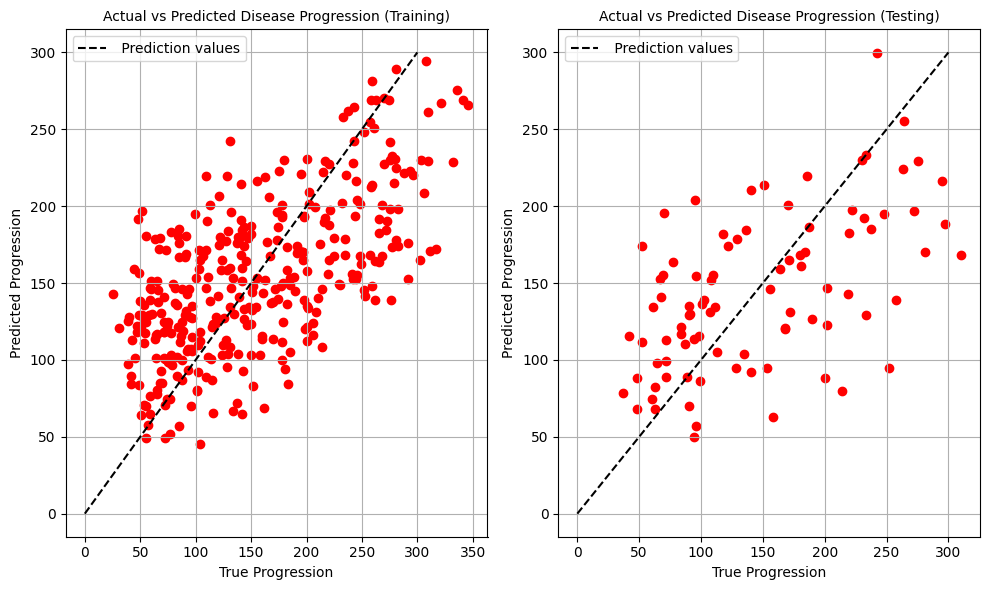

In [62]:
# make some visualizations on traing and testing data

plt.figure(figsize=(10, 6))

# subplot 1
plt.subplot(1,2,1)   # as a matrix 1 row, 1 column, the first plot
plt.scatter(y_train, y_pred_train, color = 'red')
plt.plot([0, 300], [0, 300], '--k', label=" Prediction values")
plt.axis('tight')
plt.xlabel('True Progression')
plt.ylabel('Predicted Progression')
plt.title("Actual vs Predicted Disease Progression (Training)", fontsize=10)
plt.legend()
plt.grid(True)
plt.tight_layout()

# subplot 2
plt.subplot(1,2,2)   # as a matrix 1 row, 1 column, the second plot
plt.scatter(y_test, y_pred_test, color = 'red')
plt.plot([0, 300], [0, 300], '--k', label=" Prediction values")
plt.axis('tight')
plt.xlabel('True Progression')
plt.ylabel('Predicted Progression')
plt.title("Actual vs Predicted Disease Progression (Testing)", fontsize=10)
plt.legend()
plt.grid(True)
plt.tight_layout()

**Step 8**: evaluate the model in terms of MSE, MAE, and R2_score

In [63]:
# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred_test)
print('Mean Square Error  :', mse)

mae = mean_absolute_error(y_test, y_pred_test)
print('Mean Absolute Error: ', mae)

r2 = r2_score(y_test, y_pred_test)
print('R2 ----------------:', r2)

Mean Square Error  : 3756.8366496443828
Mean Absolute Error:  50.018817544725025
R2 ----------------: 0.2909156196410876


**Step 9**: test the model on new cases

Using the model we created, predict the disease progression of two new patients:

* Patient 1: age 45, bmi of 26.3, and average blood pressure of 98

* Patient 2: age 39, bmi of 22.7, and average blood pressure of 114

*Note*: you must create a dataframe containing with the information of the new patients:

> new_patient_data = pd.DataFrame(new_patient_data_here, columns =["AGE", "BMI", "BP"])



In [64]:
new_data = pd.DataFrame({
    'AGE': [45, 39],
    'BMI': [26.3, 22.7],
    'BP': [98, 114],
})

new_data_df = pd.DataFrame(new_data)
new_data_df

,AGE,BMI,BP
0,45,26.3,98
1,39,22.7,114


In [65]:
# Predict using the model
predicted_diabeties = model.predict(new_data_df)

# Add the predicted prices to the DataFrame
new_data_df['Predicted_Diabeties'] = predicted_diabeties

# Display the DataFrame with predicted diabeties
new_data_df

,AGE,BMI,BP,Predicted_Diabeties
0,45,26.3,98,154.854686
1,39,22.7,114,142.301619


---


**You can practice with more examples .... GOOD LUCK :)**


---